In [5]:
""""""""""
Ma démarche de reflexion sera inscrite en commentaire


Mon tableau final posséde cette structure avec les colonne tconst, original title et genre
(704712, 3)

Le top 5 de genre_film est le suivant:

Drama	186876
Documentary	108063
Comedy	91372
Romance	40417
Action	38207

J'ai créé un tableau avec uniquement ces 5 genres. A discuter ensemble. VALIDE


"""""""""""

'"\nMa démarche de reflexion sera inscrite en commentaire\n\n\nMon tableau final posséde cette structure avec les colonne tconst, original title et genre\n(704712, 3)\n\nLe top 5 de genre_film est le suivant:\n\nDrama\t186876\nDocumentary\t108063\nComedy\t91372\nRomance\t40417\nAction\t38207\n\nJ\'ai créé un tableau avec uniquement ces 5 genres. A discuter ensemble. VALIDE\n\n\n'

In [6]:
import numpy as np

In [7]:
url_basics =  "https://datasets.imdbws.com/title.basics.tsv.gz"   #création de la variable permettant de stocké le chemin d'accée

import pandas as pd

df_basics = pd.read_csv(
    url_basics,
    sep="\t",
)




In [8]:
df_basics.head() #Voyons voir ce qu'il y a dedans

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
0,tt0000001,short,Carmencita,Carmencita,0,1894,\N,1,"Documentary,Short"
1,tt0000002,short,Le clown et ses chiens,Le clown et ses chiens,0,1892,\N,5,"Animation,Short"
2,tt0000003,short,Poor Pierrot,Pauvre Pierrot,0,1892,\N,5,"Animation,Comedy,Romance"
3,tt0000004,short,Un bon bock,Un bon bock,0,1892,\N,12,"Animation,Short"
4,tt0000005,short,Blacksmith Scene,Blacksmith Scene,0,1893,\N,1,Short


In [9]:
#Ok explorons tytleType

df_basics["titleType"].value_counts()

titleType
tvEpisode       9461208
short           1110933
movie            736858
video            321277
tvSeries         294149
tvMovie          153801
tvMiniSeries      67979
tvSpecial         56894
videoGame         47597
tvShort           10894
tvPilot               1
Name: count, dtype: int64

In [10]:
#là je filtre uniquement les lignes dont le titletyp est un movie ou un short. Les autres sont inutiles.

df_basics_filtered = df_basics[
    df_basics["titleType"].isin(["movie"])
]

df_basics_filtered.head()
df_basics_filtered["titleType"].value_counts() #Donc là on est bon

titleType
movie    736858
Name: count, dtype: int64

In [11]:
#Ensuite sur mon tableau, j'enleve les ligne sont isAdult=1

df_basics_filtered = df_basics_filtered[
    df_basics_filtered["isAdult"] == 0
]

df_basics_filtered.shape

df_basics_filtered["isAdult"].value_counts() #je vérifie que le filtrage s'est bien appliqué


isAdult
0    727582
Name: count, dtype: int64

In [12]:
#Ok donc là dans genre j'ai à la fois le genre et le format donc je dois la slicer en deux colonne [Genre] et [format]
#Après vérification ci dessus. Short est bien un genre et non un format ici donc je garde
#donc on fait plutot un explode afin de dupliquer les films et qu'ils puissent réagir correctement aux filtres que l'on créera

df_genres = df_basics_filtered.copy()   #je le copie pour pouvoir revenir en arriere

df_genres["genres"] = df_genres["genres"].str.split(",")
df_genres = df_genres.explode("genres")
df_genres["genres"] = df_genres["genres"].str.strip()

df_genres.sample(20)

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
1951690,tt11778026,movie,Mr Lee: 20 Years of Power,Mr Lee: 20 Years of Power,0,2020,\N,\N,Documentary
56793,tt0057914,movie,Cavalry Charge,La carga de la policía montada,0,1965,\N,101,Drama
10314360,tt5618302,movie,Babamin Namusu,Babamin Namusu,0,1986,\N,75,Comedy
301818,tt0315526,movie,The Boss,Dumok,0,1994,\N,93,Action
11478596,tt8209632,movie,Nice to Meet You,Yu jian ni zhen hao,0,2018,\N,99,Romance
6573552,tt27621606,movie,The Devil's Signature,Dablova sbirka,0,2024,\N,87,Mystery
52658,tt0053682,movie,Brücke des Schicksals,Brücke des Schicksals,0,1960,\N,101,Drama
1375242,tt10737358,movie,Outsiders,No Running,0,2021,\N,85,Mystery
3639892,tt14912006,movie,Bull Shark,Bull Shark,0,2022,\N,80,Drama
5875756,tt2317225,movie,The Machine,The Machine,0,2013,\N,91,Sci-Fi


In [13]:
# Nettoyage \N dans genres  :

#Etape 1: Droper les ligner avec \N dans genre
df_genres = df_genres[df_genres["genres"] != "\\N"]

df_genres["genres"].isna().sum() #BON


np.int64(0)

In [14]:
  #Pour la colonne "StartYear":

  #Convertion en date:
  df_genres["startYear"] = pd.to_numeric(df_genres["startYear"], errors="coerce")

  # Filtre ANNÉES : 1940–2025
  df_genres= df_genres[(df_genres["startYear"] >= 1940) & (df_genres["startYear"] <= 2025)]
  print("Après années 1995-2025:", df_genres.shape)


Après années 1995-2025: (791744, 9)


In [15]:
#Nettoyage \N dans start Year

df_genres = df_genres.replace("\\N", pd.NA)
df_genres = df_genres.dropna(subset=["startYear"])

In [16]:
df_basics.shape

(12261591, 9)

In [17]:
# Ensuite je dois enlever les genres suivants: Reality_TV, Talk-Show, Game-Show, News, Sport:

genres_a_exclure = [
    "Reality-TV",
    "Talk-Show",
    "Game-Show",
    "News",
    "Sport"
]

df_genres = df_genres[
    ~df_genres["genres"].isin(genres_a_exclure)

]




In [18]:
#regarder le noms des colonnes

df_genres.columns

Index(['tconst', 'titleType', 'primaryTitle', 'originalTitle', 'isAdult',
       'startYear', 'endYear', 'runtimeMinutes', 'genres'],
      dtype='object')

In [19]:
#là je garde uniquement les fils entre 60 (dans ce cas ci) et 210 min


df_genres["runtimeMinutes"] = pd.to_numeric(
    df_genres["runtimeMinutes"],
    errors="coerce"
)

df_genres = df_genres[
    df_genres["runtimeMinutes"].between(60, 210)
]

df_genres.shape

(594252, 9)

In [34]:
#je garde uniquement les colomne dont j'ai besoin pour le filtre genre:
    #tconst → identifiant unique IMDb (je suppose que ça sera ma clé pour construire notre Dataframe final)
    #originalTitle → le titre du film
    #genres → la base de ton filtre


#Ok on va d'abord faire un copie pour protéger l'original

df_final=df_genres.copy()


df_final = df_final.drop(columns=[ 'endYear', 'runtimeMinutes', 'titleType', 'primaryTitle' , "isAdult"])

df_final.head()

,tconst,originalTitle,startYear,genres
15478,tt0015724,Dama de noche,1993.0,Drama
15478,tt0015724,Dama de noche,1993.0,Mystery
15478,tt0015724,Dama de noche,1993.0,Romance
18586,tt0018867,Escape from Hong Kong,1942.0,Adventure
18586,tt0018867,Escape from Hong Kong,1942.0,Mystery


In [35]:
df_final.sample(20)

,tconst,originalTitle,startYear,genres
4664853,tt1765913,Metal Messiah,2010.0,Drama
10135614,tt5216534,Digimon Adventure tri. 2: Ketsui,2016.0,Animation
10734289,tt6567816,Khalil bad el-Tadil,1987.0,Comedy
43322,tt0044110,Ten Tall Men,1951.0,Action
841179,tt0869118,Point of Fear,2006.0,Mystery
11796192,tt8907986,Angrezi Medium,2020.0,Comedy
9665336,tt4150102,uSkroef noSexy,2012.0,Comedy
238070,tt0248673,Aparan,1988.0,Mystery
8271112,tt3437334,The Brother,2012.0,Comedy
832033,tt0859641,The First Breath of Tengan Rei,2009.0,Drama


In [36]:
df_genres = df_genres.drop_duplicates(
    subset=["tconst", "genres"]
)

In [37]:
#Allez, un petit value_counts() pour voir tout les genres différents maintenant:

df_genres['genres'].value_counts()


genres
Drama          161859
Comedy          80905
Documentary     74258
Romance         35086
Action          34928
Thriller        29573
Crime           28998
Horror          25989
Adventure       19728
Mystery         13672
Family          13568
Biography       12472
Fantasy         10749
History         10456
Music           10112
Sci-Fi           8206
Musical          6667
War              6620
Animation        6342
Western          3280
Film-Noir         784
Name: count, dtype: int64

In [38]:
#Les genres presents sont :
genre_counts = df_final["genres"].value_counts()
genre_counts

genres
Drama          161859
Comedy          80905
Documentary     74258
Romance         35086
Action          34928
Thriller        29573
Crime           28998
Horror          25989
Adventure       19728
Mystery         13672
Family          13568
Biography       12472
Fantasy         10749
History         10456
Music           10112
Sci-Fi           8206
Musical          6667
War              6620
Animation        6342
Western          3280
Film-Noir         784
Name: count, dtype: int64

In [39]:
#je veux savoir le top genre

top_genres = df_final["genres"].value_counts().head(10)
top_genres

genres
Drama          161859
Comedy          80905
Documentary     74258
Romance         35086
Action          34928
Thriller        29573
Crime           28998
Horror          25989
Adventure       19728
Mystery         13672
Name: count, dtype: int64

In [40]:
df_final.shape

(594252, 4)

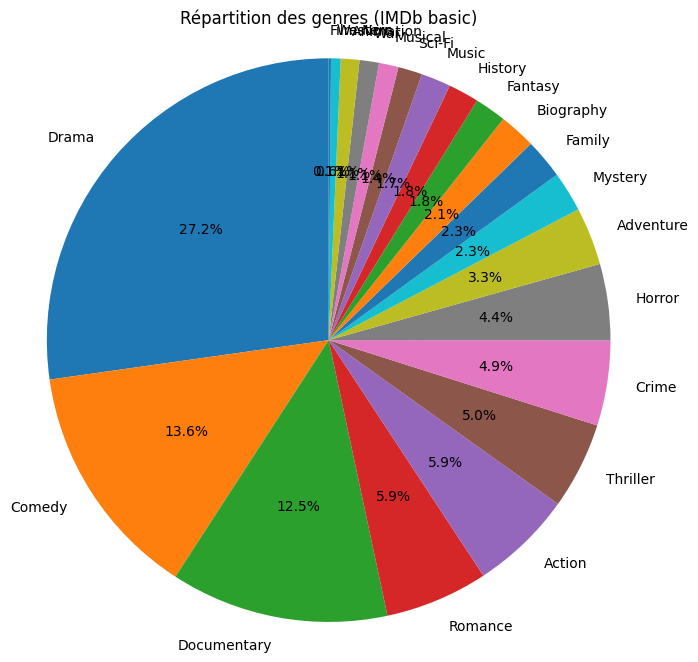

In [41]:
#Petit visuel voir ce que ça donne

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.pie(
    genre_counts,
    labels=genre_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Répartition des genres (IMDb basic)")
plt.axis("equal")  # pour un cercle bien rond
plt.show()

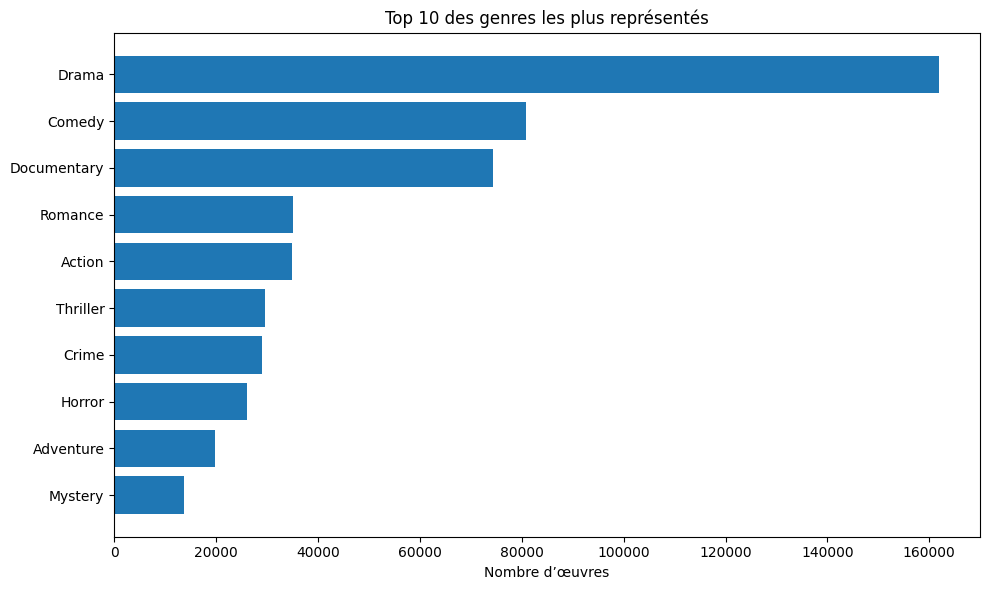

In [42]:
#Trop de catégories, plutot un bar chart horizontal du coup. Plus pertinent:

plt.figure(figsize=(10, 6))
plt.barh(top_genres.index[::-1], top_genres.values[::-1])
plt.title("Top 10 des genres les plus représentés")
plt.xlabel("Nombre d’œuvres")
plt.tight_layout()
plt.show()


In [43]:
#création d'un tableau avec uniquement le top 5 genres?

top5 = ["Drama", "Documentary", "Comedy", "Romance", "Action"]

df_genres5 = df_final[df_final["genres"].isin(top5)]

df_genres5.head()

,tconst,originalTitle,startYear,genres
15478,tt0015724,Dama de noche,1993.0,Drama
15478,tt0015724,Dama de noche,1993.0,Romance
21702,tt0022064,Lebbra bianca,1951.0,Drama
23701,tt0024121,Houkutuslintu,1946.0,Drama
25106,tt0025557,El negro que tenía el alma blanca,1951.0,Drama


In [44]:
df_genres5.shape

(387036, 4)

In [46]:
df_genres5.to_csv("df_genres_5.csv", index=False)

